<a href="https://colab.research.google.com/github/jeremysb1/grokking-statistics/blob/main/Chapter_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Central Limit Theorem
from scipy.stats import norm
from math import sqrt

mu = 98.2
sigma = .73
n = 31

mu_sample_means = mu
sigma_sample_means = sigma/sqrt(n)

A = norm.cdf(98.0, mu_sample_means, sigma_sample_means)

print(f"P(sample mean < 98.0): {A: .4f}")

P(sample mean < 98.0):  0.0636


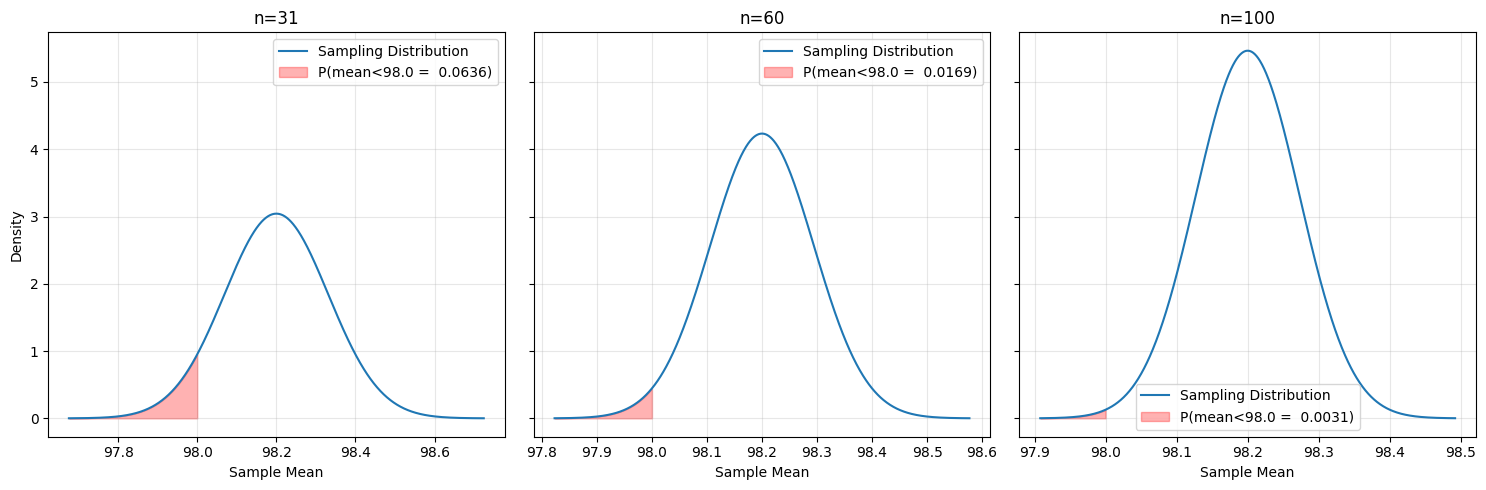

In [4]:
# increased the sample size
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
from math import sqrt

mu = 98.2
sigma = 0.73
n_values = [31, 60, 100]
x_target = 98.0

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for i, n in enumerate(n_values):
    mu_sample_means = mu
    sigma_sample_means = sigma/sqrt(n)

    x = np.linspace(mu-4*sigma_sample_means, mu+4*sigma_sample_means, 1000)
    y = norm.pdf(x, mu_sample_means, sigma_sample_means)

    prob = norm.cdf(x_target, mu_sample_means, sigma_sample_means)

    axes[i].plot(x, y, label='Sampling Distribution')

    x_fill = np.linspace(mu - 4*sigma_sample_means, x_target, 100)
    y_fill = norm.pdf(x_fill, mu_sample_means, sigma_sample_means)
    axes[i].fill_between(x_fill, y_fill, alpha=0.3, color='red',
                         label=f'P(mean<{x_target} = {prob: .4f})')

    axes[i].set_title(f'n={n}')
    axes[i].set_xlabel('Sample Mean')
    if i ==0:
        axes[i].set_ylabel('Density')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
# z-values
from scipy.stats import norm

mu, sigma = 0, 1
z = norm.ppf(0.025, mu, sigma)

print(f"Z-Value that captures .025 area: {z:.6f}")

Z-Value that captures .025 area: -1.959964


In [9]:
mu, sigma = 0, 1
z = norm.ppf(0.975, mu, sigma)

print(f"Z-Values that captures .975 area: {z:.6f}")

Z-Values that captures .975 area: 1.959964


In [8]:
mu, sigma = 0, 1
A = .95
z = norm.ppf(1 - (1 - A) / 2, mu, sigma)

print(f"Z-value that captures {A} area: ±{z:.6f}")


Z-value that captures 0.95 area: ±1.959964


In [11]:
# 95% confidence interval
import scipy.stats as stats
import numpy as np

mean = 7.5
std = 2.5
n = 100
confidence = 0.95

z = stats.norm.ppf(1 - (1 - confidence)/2)
se = std/np.sqrt(n)

margin = 2 * se

lower = mean - margin
upper = mean + margin

print(f"95% Confidence Interval:  ({lower: .3f}, {upper: .3f})")

95% Confidence Interval:  ( 7.000,  8.000)


In [12]:
# 99% Confidence Interval

mean = 7.5
std = 2.5
n = 100

confidences = [.95, .99, .999]

for c in confidences:
    z = stats.norm.ppf(1 - (1 - c)/2)
    se = std/np.sqrt(n)
    margin = z * se
    lower = mean - margin
    upper = mean + margin

    print(f"{(c*100): .1f}% Confidence Interval: ({lower: .3f}, {upper: .3f})")

 95.0% Confidence Interval: ( 7.010,  7.990)
 99.0% Confidence Interval: ( 6.856,  8.144)
 99.9% Confidence Interval: ( 6.677,  8.323)
